[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/04_machine_learning/14_sklearn_basics.ipynb)

# 📓 Notebook 14 — Scikit-Learn Basics: Customer Churn and Feedback Classification

> **Module:** Machine Learning · **Estimated time:** 70–90 min · **Difficulty:** Intermediate

This is where everything you have learned converges. NumPy gave us arrays, pandas gave us tables, matplotlib gave us charts. **Scikit-learn** gives us a beautifully uniform toolkit for training, evaluating, and using machine-learning models.

Rather than the classic Iris flowers and California housing demos, this notebook works through **two end-to-end business-AI projects**:

1. **Customer churn prediction** — classification on a synthetic SaaS dataset.
2. **Customer satisfaction prediction** — regression on the same dataset.

The patterns you learn — train/test split, pipelines, cross-validation, feature importance — are exactly the patterns used in production ML systems.

## 🎯 Learning objectives

1. Walk through the **scikit-learn workflow**: split → fit → predict → evaluate → iterate.
2. Build classification models (Logistic Regression, Random Forest, k-NN) and compare them.
3. Use **`Pipeline`** to bundle preprocessing with the model — and avoid data leakage.
4. Evaluate classifiers with the **confusion matrix**, precision/recall, and F1.
5. Train and evaluate regression models with **MAE**, **RMSE**, **R²**.
6. Run **cross-validation** for honest performance estimates.
7. Tune hyperparameters with **`GridSearchCV`**.
8. Read **feature importances** to interpret what the model relied on.

## ✅ Prerequisites

Notebooks 1–11.

## 1. The ML workflow in one picture

```
                     ┌──────────────────────────────────────────┐
                     │  1. Load and explore the data            │
                     │  2. Prepare features (X) and target (y)  │
   Raw data ────────►│  3. Split into train / test              │
                     │  4. Fit a model on train (`.fit`)        │
                     │  5. Predict on test (`.predict`)         │
                     │  6. Evaluate against the truth           │
                     │  7. Iterate: try other models / features │
                     └──────────────────────────────────────────┘
```

The exact same seven-step pattern applies to classification, regression, clustering, and beyond.

## 2. Setup

In [ ]:
# The Big 3 + scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Split, validation, tuning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# Preprocessing & pipelines
from sklearn.preprocessing import StandardScaler
from sklearn.compose       import ColumnTransformer
from sklearn.pipeline      import Pipeline

# Classifiers
from sklearn.linear_model  import LogisticRegression
from sklearn.tree          import DecisionTreeClassifier
from sklearn.neighbors     import KNeighborsClassifier
from sklearn.ensemble      import RandomForestClassifier

# Regressors
from sklearn.linear_model  import LinearRegression
from sklearn.ensemble      import RandomForestRegressor

# Metrics
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score,
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

print("Scikit-learn ready ✅")

## 3. Project 1 — Customer churn prediction 📉

A SaaS company wants to predict which customers are about to churn. We will use a small **synthetic** dataset so the notebook is self-contained and reproducible — but every column corresponds to something you would measure in a real CRM.

### 3.1 Generate the dataset

In [ ]:
rng = np.random.default_rng(RANDOM_STATE)
n = 600

# Underlying customer characteristics
mrr_eur         = rng.lognormal(mean=6.5, sigma=0.7, size=n).clip(50, 50_000)
months_active   = rng.integers(1, 60, size=n)
support_tickets = rng.poisson(lam=2.5, size=n)
plan            = rng.choice(["Free", "Standard", "Premium", "Enterprise"],
                              size=n, p=[0.15, 0.45, 0.30, 0.10])
last_login_days = rng.integers(0, 90, size=n)

# Latent customer "happiness" — drives BOTH the NPS score and the churn outcome
# (i.e., they share a common cause, which is what makes this a realistic dataset)
plan_adj = np.array([{"Free": -0.45, "Standard": 0.0,
                      "Premium": 0.15, "Enterprise": 0.35}[p] for p in plan])

happiness = (
    -0.40 * (support_tickets - 2.5) / 2.0          # many tickets → unhappy
    -0.80 * (last_login_days - 45) / 30.0          # absent users → unhappy
    +0.35 * (np.log1p(mrr_eur) - 6.5) / 1.5        # higher MRR → mildly happier
    +0.30 * (months_active - 30) / 20.0            # tenure helps
    + plan_adj
    + rng.normal(0, 0.30, n)                       # noise
)

# NPS is happiness mapped to a -100..100 scale, plus measurement noise
nps = (40 + 35 * happiness + rng.normal(0, 8, n)).clip(-100, 100)

# Churn outcome: logistic on happiness — about 30% churn rate overall
churn_prob = 1 / (1 + np.exp(-(-1.6 - 2.5 * happiness)))
churned    = (rng.random(n) < churn_prob).astype(int)

churn_df = pd.DataFrame({
    "mrr_eur":         mrr_eur.round(2),
    "months_active":   months_active,
    "support_tickets": support_tickets,
    "nps":             nps.round(1),
    "plan":            plan,
    "last_login_days": last_login_days,
    "churned":         churned,
})

print(f"Shape          : {churn_df.shape}")
print(f"Churn rate     : {churn_df['churned'].mean():.1%}")
print(f"Plan balance   : {churn_df['plan'].value_counts().to_dict()}")
churn_df.head()


> 💡 **A note on synthetic data.** We engineered a plausible churn signal so the demo works without a real dataset. The patterns the model learns — login recency matters, NPS matters, free-plan churns more — are *qualitatively* correct, just like in real-world SaaS data.

### 3.2 Explore the target

Always check class balance before anything else. A 50/50 split needs a different approach than a 95/5 split.

In [ ]:
print(churn_df["churned"].value_counts(normalize=True).round(3))


In [ ]:
# Visual sanity check — churn rate by plan and by NPS bucket
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

plans = ["Free", "Standard", "Premium", "Enterprise"]
churn_df.groupby("plan")["churned"].mean().reindex(plans).plot(
    kind="bar", ax=axes[0], title="Churn rate by plan", ylabel="churn rate", rot=0)

buckets = pd.cut(churn_df["last_login_days"], bins=[-1, 7, 30, 60, 90],
                 labels=["≤ 7d", "8–30d", "31–60d", "61–90d"])
churn_df.groupby(buckets, observed=False)["churned"].mean().plot(
    kind="bar", ax=axes[1], title="Churn rate by login recency", rot=0)

for ax in axes:                                   # % labels on top of each bar
    ax.bar_label(ax.containers[0], fmt="{:.0%}")
fig.tight_layout();

**Observations.** Free-plan customers churn at a much higher rate than Enterprise. Customers who haven't logged in for more than 60 days are *very* likely to churn. That tells us the model has signal to learn — and these two features will probably end up at the top of the feature-importance ranking.

### 3.3 Train / test split

We hold out **20%** of the data as a test set we won't touch until the very end. `stratify=y` keeps the churn rate the same in both splits — essential whenever the target is imbalanced.

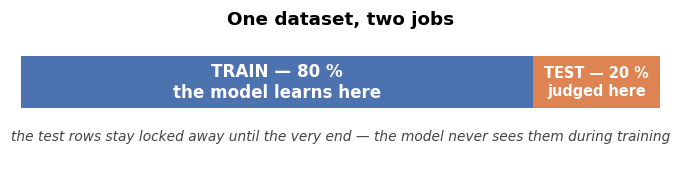

In [ ]:
X = churn_df.drop(columns=["churned"])
y = churn_df["churned"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train shape : {X_train.shape} → churn rate {y_train.mean():.1%}")
print(f"Test shape  : {X_test.shape}  → churn rate {y_test.mean():.1%}")


### 3.4 The scikit-learn API contract

Every estimator follows the same shape — that's the genius of scikit-learn:

```python
model = SomeModel(hyperparam=value)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
score  = model.score(X_test, y_test)
```

This uniformity means **swapping a logistic regression for a random forest is a one-line change.**

### 🔬 What actually happens inside `.fit()` and `.predict()`?

The contract above hides a beautifully simple idea. A scikit-learn model is just an
object with two jobs:

- **`fit(X, y)` = *learn-and-remember*.** It looks at the training data, computes the
  best numbers it can, and **stores them on the object** under names that end in a
  trailing underscore — `coef_`, `intercept_`, `classes_`, and so on. The `_` suffix
  is sklearn's convention for *"this was learned from data during `fit`."*
- **`predict(X)` = *apply the remembered numbers*.** It does **no learning**. It just
  plugs new inputs into the formula built from those stored attributes.

```text
   training data                          new inputs
   X_train, y_train                       X_new
        │                                    │
        ▼                                    ▼
   ┌─────────┐    learns &  ┌────────────┐  applies  ┌──────────────┐
   │  .fit() │ ───────────► │ stored     │ ────────► │ .predict()    │
   │ learn & │    stores    │ params:    │  formula  │ X_new @ coef_ │
   │ remember│              │ coef_      │           │   + intercept_│
   └─────────┘              │ intercept_ │           └──────┬───────┘
                            └────────────┘                  ▼
                                                       predictions
```

For a `LinearRegression`, the "remembered numbers" are literally a slope per feature
(`coef_`) and an offset (`intercept_`). Once you know that, `predict` is no longer
magic — it's one line of arithmetic you can reproduce by hand. Let's prove it.

#### Step 1 — `fit` on a tiny inline dataset, then read what it *learned*

We make a tiny 2-feature dataset where we *secretly* know the true rule:

`y = 3 + 2·x₁ − 1·x₂`  (intercept 3, slope +2 on `x1`, slope −1 on `x2`).

After `fit`, the model should have **recovered** those numbers and parked them in
`coef_` and `intercept_`.

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Tiny, self-contained training set (no downloads).
X_demo = np.array([
    [1.0, 0.0],
    [2.0, 1.0],
    [3.0, 2.0],
    [0.0, 4.0],
    [4.0, 1.0],
])
# True rule:  y = 3 + 2*x1 - 1*x2   (we know this; the model does NOT)
y_demo = 3 + 2 * X_demo[:, 0] - 1 * X_demo[:, 1]

model = LinearRegression()
model.fit(X_demo, y_demo)        # <-- learn-and-remember

# The learned parameters live on the object, with trailing underscores:
print("model.coef_      =", model.coef_)        # one slope per feature
print("model.intercept_ =", model.intercept_)   # the offset
print()
print("Recovered the secret rule? coef ≈ [2, -1], intercept ≈ 3 ->",
      np.allclose(model.coef_, [2, -1]) and np.isclose(model.intercept_, 3))

> 💡 The numbers printed above were **not** in our code — `fit` *derived* them from
> `X_demo`/`y_demo` and stored them. That storage is the model's entire memory.
> A model that hasn't been fitted has **no** `coef_` attribute yet; it appears only
> after `.fit()` runs.

#### Step 2 — `predict` is just *apply the remembered numbers*

`predict` doesn't peek at the training data again. For linear regression the formula
is exactly:

```text
prediction = X_new @ coef_ + intercept_
```

Let's reproduce **one** prediction by hand and `assert` it matches `model.predict`.

In [ ]:
# A brand-new input the model has never seen:
x_new = np.array([[5.0, 2.0]])

# What sklearn says:
sklearn_pred = model.predict(x_new)

# The same thing, by hand, using ONLY the stored params:
by_hand = x_new @ model.coef_ + model.intercept_   # X @ coef_ + intercept_

print("model.predict(x_new) =", sklearn_pred)
print("by hand (X@coef_+b)  =", by_hand)

# Proof they are identical (and match the true rule 3 + 2*5 - 1*2 = 11):
assert np.allclose(sklearn_pred, by_hand), "hand formula must match predict()"
assert np.isclose(sklearn_pred[0], 3 + 2*5 - 1*2)
print("\n✅ predict() == X @ coef_ + intercept_  — no magic, just stored numbers.")

> 🧠 **Mental model.** `fit` = *learn-and-remember* (it writes the answers into
> `_`-suffixed attributes); `predict` = *apply the remembered numbers* to new inputs.
> Training happens **once**; prediction reuses the frozen parameters as many times as
> you like.
>
> 🎯 **Why this matters.** This is why a `Pipeline` is safe: preprocessing steps learn
> their numbers (e.g. a scaler's mean/std) from the **training** data only, store them,
> and re-apply the exact same numbers to the test data — never re-learning on data
> they'll be judged on.
>
> ⚠️ **Common trap.** Calling `.predict()` (or `.coef_`) before `.fit()` raises
> `NotFittedError` / `AttributeError` — there's nothing remembered yet. And every
> classifier/regressor in this notebook (`LogisticRegression`, `RandomForestRegressor`,
> …) follows the *same* learn-then-apply lifecycle; only *what* gets stored differs.

### 3.5 A preprocessing pipeline

Our features mix **numeric** and **categorical** types. We need to:

- Standardise numeric columns (mean 0, std 1).
- One-hot encode the `plan` column.

We do all of this inside a `Pipeline` so the preprocessing is fit on the *training data only*, then re-applied identically to the test data. That single discipline avoids one of the most damaging beginner mistakes: **data leakage**.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

numeric_cols     = ["mrr_eur", "months_active", "support_tickets", "nps", "last_login_days"]
categorical_cols = ["plan"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(),                                  numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"),            categorical_cols),
    ],
    remainder="drop",
)

# Sanity check — fit on the training data, look at the output shape
X_train_t = preprocess.fit_transform(X_train)
print(f"Transformed train shape: {X_train_t.shape}")
print(f"Feature names: {preprocess.get_feature_names_out().tolist()}")


### 3.6 Train and compare four classifiers

Same `Pipeline` skeleton — only the final model changes.

In [ ]:
classifiers = {
    "Logistic Regression":  LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
    "Decision Tree":        DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=6),
    "k-NN (k=7)":           KNeighborsClassifier(n_neighbors=7),
    "Random Forest":        RandomForestClassifier(n_estimators=200,
                                                   random_state=RANDOM_STATE,
                                                   n_jobs=-1),
}

results = {}
for name, clf in classifiers.items():
    pipe = Pipeline([("prep", preprocess), ("model", clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = (pipe, acc)
    print(f"  {name:<22}  accuracy = {acc:.3f}")

# Best model
best_name = max(results, key=lambda k: results[k][1])
best_pipe = results[best_name][0]
print(f"\nBest on this test set: {best_name}")


Accuracy is a useful headline but it hides asymmetric errors. A churn model that misses a real churner is more costly than one that flags a happy customer — they need different metrics. The confusion matrix shows both.

### 3.7 A closer look — the confusion matrix

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred_best = best_pipe.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best,
                                        display_labels=["stayed", "churned"], cmap="Blues")
plt.title(f"Confusion matrix — {best_name}")
plt.show()

print(classification_report(y_test, y_pred_best,
                            target_names=["stayed", "churned"],
                            digits=3, zero_division=0))

**Reading the matrix.** Diagonal = correct predictions, off-diagonal = mistakes. The classification report adds three per-class metrics:

- **Precision** = "of customers the model flagged as churners, how many actually churned?"
- **Recall** = "of customers who actually churned, how many did the model catch?"
- **F1-score** = harmonic mean of precision and recall — a balanced single number.

Which metric you optimise depends on the business cost:

- **High precision** matters when acting on a flag is expensive (e.g., sending a sales person).
- **High recall** matters when *missing* a churner is expensive (you've lost a customer).

### 3.8 Predicting on new customers — with probabilities

In [ ]:
# Five hand-crafted customer profiles
new_customers = pd.DataFrame([
    {"mrr_eur": 199,   "months_active":  3, "support_tickets": 0,
     "nps": -10, "plan": "Free",       "last_login_days": 75},     # high risk
    {"mrr_eur": 2_400, "months_active": 36, "support_tickets": 1,
     "nps": 65,  "plan": "Premium",    "last_login_days":  2},     # low risk
    {"mrr_eur":   850, "months_active": 12, "support_tickets": 3,
     "nps": 40,  "plan": "Standard",   "last_login_days": 20},     # medium
    {"mrr_eur": 5_900, "months_active": 48, "support_tickets": 8,
     "nps":  5,  "plan": "Enterprise", "last_login_days": 45},     # complicated
    {"mrr_eur":    99, "months_active":  6, "support_tickets": 0,
     "nps": 80,  "plan": "Free",       "last_login_days":  1},     # contradictory
])

pred = best_pipe.predict(new_customers)
prob = best_pipe.predict_proba(new_customers)[:, 1]   # P(churn)

for i, (p, pr) in enumerate(zip(pred, prob)):
    print(f"  Customer {i}: predicted = {'churn' if p else 'stay'}    P(churn) = {pr:.2%}")


**Expose the probability, not just the label.** A `0/1` decision throws away information. `P(churn) = 0.51` and `P(churn) = 0.95` are both "churn" but tell you very different things about how to *act* on the prediction. Calibration and probabilities are how serious ML systems make business sense of model output.

### 3.9 Feature importance — what is the model relying on?

A trained Random Forest can tell you which features it actually used. This is the cheapest interpretability tool you have.

In [ ]:
rf_pipe = results["Random Forest"][0]

importance = pd.Series(
    rf_pipe.named_steps["model"].feature_importances_,
    index=rf_pipe.named_steps["prep"].get_feature_names_out(),
).sort_values()

importance.plot(kind="barh", title="Random-Forest feature importance — churn prediction",
                xlabel="relative importance", figsize=(8, 5))

print("Top 5 features:")
print(importance.tail(5)[::-1].round(3).to_string())

**Reading the bar chart.** The top features should match your business intuition (login recency, plan, NPS). If a feature you *didn't* expect is at the top, that's worth investigating — it's often where leakage hides.

## 4. Project 2 — Predicting customer satisfaction 📈

Now a **regression** task on the same dataset: predict the customer's NPS score from the other features.

(In a real product you'd be predicting something more actionable — expected MRR for next month, expected support cost, churn probability across time. NPS is a clean scalar that works well for the demo.)

### 4.1 Train / test split

In [ ]:
X_reg = churn_df.drop(columns=["nps", "churned"])
y_reg = churn_df["nps"].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=RANDOM_STATE
)
print(f"Train: {X_tr.shape}, Test: {X_te.shape}")

# Different numeric columns this time — we dropped 'nps' from the inputs
reg_numeric = ["mrr_eur", "months_active", "support_tickets", "last_login_days"]
reg_cat     = ["plan"]
reg_prep = ColumnTransformer([
    ("num", StandardScaler(),                       reg_numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore"), reg_cat),
])


### 4.2 A first regression pipeline — Linear Regression

In [ ]:
pipe_lin = Pipeline([("prep", reg_prep), ("model", LinearRegression())])
pipe_lin.fit(X_tr, y_tr)
yhat_lin = pipe_lin.predict(X_te)

print("Linear Regression:")
print(f"  MAE  = {mean_absolute_error(y_te, yhat_lin):.2f}")
print(f"  RMSE = {mean_squared_error(y_te, yhat_lin) ** 0.5:.2f}")
print(f"  R²   = {r2_score(y_te, yhat_lin):.3f}")


**How to read regression metrics:**

- **MAE** (mean absolute error) — the typical error in target units. Easy to communicate: *"on average we're off by X."*
- **RMSE** (root mean squared error) — like MAE but penalises large errors more. Use when occasional huge errors are very bad.
- **R²** (coefficient of determination) — proportion of variance explained, in [-∞, 1]. 1.0 = perfect, 0 = no better than predicting the mean.

### 4.3 A stronger model — Random Forest

In [ ]:
pipe_rf = Pipeline([
    ("prep",  reg_prep),
    ("model", RandomForestRegressor(n_estimators=200, max_depth=12,
                                    random_state=RANDOM_STATE, n_jobs=-1)),
])
pipe_rf.fit(X_tr, y_tr)
yhat_rf = pipe_rf.predict(X_te)

print("Random Forest:")
print(f"  MAE  = {mean_absolute_error(y_te, yhat_rf):.2f}")
print(f"  RMSE = {mean_squared_error(y_te, yhat_rf) ** 0.5:.2f}")
print(f"  R²   = {r2_score(y_te, yhat_rf):.3f}")


### 4.4 Predicted vs actual — a diagnostic plot

This is the single most useful regression debugging chart: plot predicted values against true ones. A perfect model lies on the diagonal.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
for ax, yhat, name in [(axes[0], yhat_lin, "Linear Regression"),
                       (axes[1], yhat_rf,  "Random Forest")]:
    sns.scatterplot(x=y_te, y=yhat, alpha=0.45, s=14, ax=ax)
    ax.axline((0, 0), slope=1, color="crimson", ls="--", label="perfect prediction")
    ax.set(xlabel="Actual NPS", ylabel="Predicted NPS", title=name)
    ax.legend()
fig.tight_layout();

A tight cloud along the diagonal means good predictions. Systematic deviations (a curve, a bias, or a fan shape) reveal where the model is wrong — and that's *much* more actionable than a single R² number.

### 4.5 Cross-validation — a more honest score

The Random-Forest R² above came from **one** train/test split — and that number is partly luck. Re-shuffle with a different `random_state` and you get a different score, because *which* customers happen to land in the test set matters. Before you tell your manager “the model explains 60 % of the variance”, you want to know how much that number wobbles.

**k-fold cross-validation** removes the luck factor:

1. Split the **training data** into `k` equal parts, called *folds* (here `k = 5`).
2. Train on 4 folds, score on the held-out fold.
3. Rotate, until every fold has been the validation fold exactly once.
4. Report the **mean** of the 5 scores — and their **standard deviation**, which tells you how stable the score is.

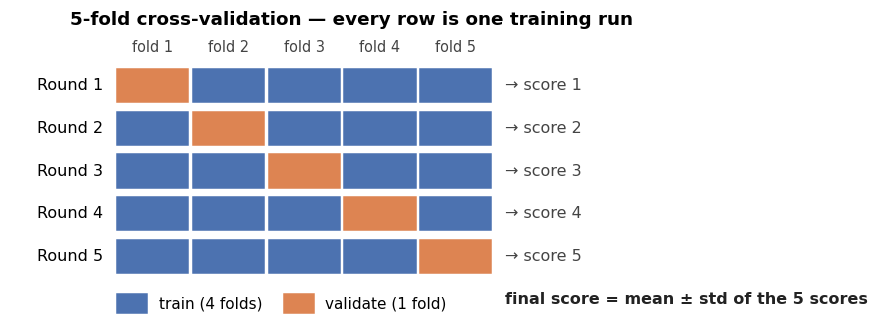

No data is wasted (every row gets validated exactly once) and nothing leaks (a model never sees its own validation fold during training). The price is honest too: you train `k` models instead of one.

In [ ]:
cv_scores = cross_val_score(pipe_rf, X_tr, y_tr, cv=5, scoring="r2", n_jobs=-1)

print(f"5-fold R² scores : {cv_scores.round(3)}")
print(f"Mean ± std       : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

**How to read this.** The mean is your honest performance estimate; the std is its error bar. A std of ±0.02 means “this score is solid”; ±0.15 means “don't quote the second digit in a slide”. If one fold scores far below the others, some segment of your data is harder — worth investigating before shipping.

Three rules that keep cross-validation honest:

1. **Cross-validate on the *training* data only** (`X_tr`, not `X_reg`). The test set stays in the vault for one final check at the very end.
2. **Cross-validate the whole `Pipeline`, not the bare model.** The preprocessing is then re-fitted *inside* each fold, so no information from a validation fold leaks into scaling or encoding. This is exactly why we pass `pipe_rf` here.
3. **For classification, keep the class balance per fold.** scikit-learn does this automatically (stratified folds) whenever the estimator is a classifier.

> 💡 `cross_val_score` trains `k` models, returns their scores, and throws the models away. If you also want multiple metrics or the fit times, use its bigger sibling `cross_validate(...)`.

### 4.6 Hyperparameter tuning with `GridSearchCV`

Every model has two kinds of knobs:

| | Who sets it | When | Examples |
|---|---|---|---|
| **Parameters** | the algorithm — *learned* by `.fit()` | during training | regression coefficients, the trees' split thresholds |
| **Hyperparameters** | *you* — chosen before training | before training | `n_estimators`, `max_depth`, `k` in k-NN |

“Is 300 trees better than 100? Should the trees be deeper?” You could answer with a hand-written loop: for every combination, cross-validate, remember the best. `GridSearchCV` **is** that loop, productized:

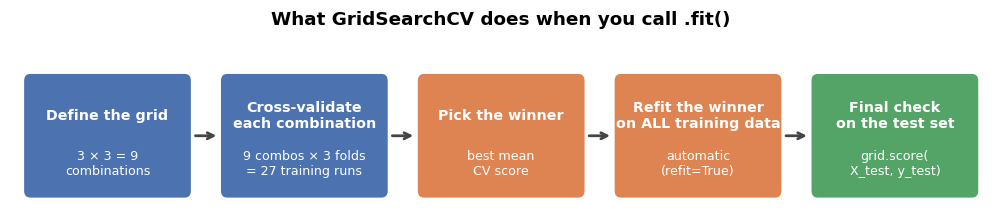

Two details to understand before reading the code:

- **The `model__n_estimators` naming.** Our pipeline has two steps, `"prep"` and `"model"`. The double underscore routes the hyperparameter to the right step: *step name* + `__` + *hyperparameter name*. That's how the grid reaches inside a `Pipeline`.
- **The cost.** A grid multiplies fast: 3 values × 3 values × 3 folds = **27 training runs** (plus one final refit). That's why we drop from 5 folds to 3 inside the search — a common cost/precision trade-off.

In [ ]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth":    [4, 8, 16],
}

grid = GridSearchCV(pipe_rf, param_grid, cv=3, scoring="r2", n_jobs=-1)
grid.fit(X_tr, y_tr)                      # 9 combinations × 3 folds = 27 training runs

print(f"Best params : {grid.best_params_}")
print(f"Best CV R²  : {grid.best_score_:.3f}")
print(f"Test  R²    : {grid.score(X_te, y_te):.3f}")   # grid now IS the refitted best model

After `.fit()`, `grid` *is* the winning model, refitted on all training data — you can call `.predict()` / `.score()` on it directly. And the full experiment log lives in `grid.cv_results_`. One pivot + one heatmap turns it into a picture:

In [ ]:
scores = (pd.DataFrame(grid.cv_results_)
            .pivot(index="param_model__max_depth",
                   columns="param_model__n_estimators",
                   values="mean_test_score"))

sns.heatmap(scores, annot=True, fmt=".3f", cmap="Blues")
plt.title("Mean CV R² per hyperparameter combination");

**Reading the heatmap.**

- Scores barely change **along a row** → `n_estimators` stops mattering after ~100–200 trees (more trees cost time, not accuracy).
- Scores change **down a column** → `max_depth` is the knob that matters here.
- If the best cell sits **on the edge** of the grid, your grid is too small — widen the range and search again.

And the comparison that actually matters: **Best CV R²** (seen during the search) vs **Test R²** (never seen). They should be close. If CV looks great and the test score is clearly worse, the search has started to overfit the validation folds — fewer combinations, more folds, or more data.

> 💡 **When the grid explodes** (4 knobs × 5 values = 625 combos), switch to `RandomizedSearchCV(..., n_iter=20)` — it samples random combinations instead of trying all of them, and usually finds a near-best setting at a fraction of the cost.

> 🎯 **The full tuning recipe:** ① split off a test set → ② `GridSearchCV` on the *training* set, with the whole `Pipeline` inside → ③ report `grid.score(X_test, y_test)` exactly once, at the end. That number is what goes in the slide.

## 5. Common ML pitfalls (and how to avoid them)

| Pitfall                                       | Symptom                                                  | Fix                                                                |
|-----------------------------------------------|----------------------------------------------------------|--------------------------------------------------------------------|
| **Data leakage** through preprocessing        | suspiciously good test scores                            | Fit transformers inside a `Pipeline` on train only.                |
| Training and evaluating on the **same data**  | 100% accuracy that doesn't generalise                    | Always `train_test_split`. Prefer cross-validation.                |
| Imbalanced classes                            | model predicts the majority class for everything         | Use `stratify=y` in the split; report precision/recall, not just accuracy. |
| Forgetting to scale features                  | distance-based models (k-NN, SVM) underperform           | Add `StandardScaler` to the pipeline.                              |
| Tuning on the test set                        | reported metrics overestimate real performance           | Tune on cross-validation, *then* score the final model on the test set once. |
| Reading off a single metric                   | nuance gets lost                                          | Always inspect a confusion matrix or a predicted-vs-actual plot.    |

## 🧪 Practice exercises

### Exercise 1 — ⭐ A different classifier on churn

Train a **k-nearest-neighbours classifier with `k=11`** on the churn dataset (same train/test split). Compute accuracy, classification report, and confusion matrix. Don't forget the preprocessing pipeline.

In [ ]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
knn_pipe = Pipeline([
    ("prep",  preprocess),
    ("model", KNeighborsClassifier(n_neighbors=11)),
])
knn_pipe.fit(X_train, y_train)

y_pred_knn = knn_pipe.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.3f}")
print(classification_report(y_test, y_pred_knn,
                            target_names=["stayed", "churned"], zero_division=0))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_knn))
```

**Note.** k-NN really needs the `StandardScaler` step inside the pipeline. Without it, features on different scales (MRR in thousands, NPS on a -100..100 axis) would dominate the distance metric.
</details>

### Exercise 2 — ⭐⭐ Feedback classification (text-as-features)

Use scikit-learn's `CountVectorizer` to turn a small batch of customer feedback into numeric features, then train a `LogisticRegression` to classify each message as `"positive"`, `"neutral"`, or `"negative"`.

In [ ]:
feedback_texts = [
    "Love the new dashboard! It's so much faster.",
    "The app crashed three times today, very frustrating.",
    "Could you add CSV export? Would be really helpful.",
    "My invoice doesn't match my plan, please refund.",
    "Everything works fine, no complaints.",
    "Customer support resolved my issue quickly. Thanks!",
    "Loading is really slow on mobile, bad experience.",
    "The new feature is great but a bit confusing.",
    "Refund taking forever, terrible service.",
    "Works well, no issues here.",
    "Fantastic update — keep up the good work!",
    "I'm cancelling, this is unusable.",
]
labels = [
    "positive", "negative", "neutral",
    "negative", "neutral",  "positive",
    "negative", "positive", "negative",
    "neutral",  "positive", "negative",
]

# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
from sklearn.feature_extraction.text import CountVectorizer

text_pipe = Pipeline([
    ("vec",   CountVectorizer(lowercase=True, ngram_range=(1, 2))),
    ("model", LogisticRegression(max_iter=500, random_state=RANDOM_STATE)),
])

# With only 12 examples we just do cross-validation rather than a held-out split
cv = cross_val_score(text_pipe, feedback_texts, labels, cv=3)
print(f"3-fold accuracy: {cv.mean():.2f} ± {cv.std():.2f}")

# Train on all and predict a few new messages
text_pipe.fit(feedback_texts, labels)
new = ["I hate the new pricing.", "Great product, well done!", "How do I export data?"]
for msg, pred in zip(new, text_pipe.predict(new)):
    print(f"  {pred:<8}  ←  {msg!r}")
```

**What just happened.** `CountVectorizer` turns each piece of text into a *bag-of-words* count vector — a number per word in the vocabulary. Logistic regression learns weights for each word. With only 12 examples performance is shaky, but the *pattern* is identical to a production classifier trained on 100K examples — same Pipeline, same `.fit` / `.predict`. The LLM-based approach in NB 17 is essentially a much smarter version of this.
</details>

### Exercise 3 — ⭐⭐ Regression with a feature subset

On the satisfaction-regression task, train a `LinearRegression` using **only `mrr_eur` and `last_login_days`**. Report R² and compare with the full-feature model.

In [ ]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
small_prep = ColumnTransformer([
    ("num", StandardScaler(), ["mrr_eur", "last_login_days"]),
])

small_pipe = Pipeline([("prep", small_prep), ("model", LinearRegression())])
small_pipe.fit(X_tr, y_tr)
r2_small = small_pipe.score(X_te, y_te)

# Compare to the full-feature linear baseline from earlier
r2_full = pipe_lin.score(X_te, y_te)

print(f"R² with 2 features  : {r2_small:.3f}")
print(f"R² with all features: {r2_full:.3f}")
print(f"Gain from extra features: {r2_full - r2_small:+.3f}")
```

A useful exercise in feature *parsimony*: most of the predictive power often comes from a handful of features. Worth knowing before you spend a week engineering 50 new ones.
</details>

### Exercise 4 — ⭐⭐ Tune `k` for k-NN

Scan `k ∈ {1, 3, 5, 7, 11, 21, 51}` on the churn dataset with 5-fold cross-validation, and plot mean accuracy vs `k`. Which `k` is best?

In [ ]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
ks = [1, 3, 5, 7, 11, 21, 51]
means, stds = [], []
for k in ks:
    pipe = Pipeline([("prep", preprocess),
                     ("model", KNeighborsClassifier(n_neighbors=k))])
    s = cross_val_score(pipe, X, y, cv=5, scoring="accuracy", n_jobs=-1)
    means.append(s.mean())
    stds.append(s.std())

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.errorbar(ks, means, yerr=stds, marker="o", linewidth=2, capsize=4, color="#4C72B0")
ax.set_xscale("log")
ax.set_xticks(ks); ax.set_xticklabels(ks)
ax.set_xlabel("k (number of neighbours)")
ax.set_ylabel("Accuracy (5-fold CV)")
ax.set_title("k-NN accuracy vs k — churn dataset")
plt.tight_layout(); plt.show()

for k, m, s in zip(ks, means, stds):
    print(f"  k={k:<3}  accuracy = {m:.3f} ± {s:.3f}")
```

You'll typically see a clear "sweet spot": too-small `k` overfits to noise, too-large `k` underfits and predicts the majority class. The grid is your friend.
</details>

### Exercise 5 — ⭐⭐ Debug me 🐞

The cell below is supposed to evaluate a logistic-regression classifier on the churn dataset. The reported accuracy is **suspiciously perfect**. What's wrong? Fix it.

In [ ]:
# 👇 Your fixed/corrected version goes here — write or paste it below.
# Buggy:
clf = LogisticRegression(max_iter=500)
clf.fit(X.select_dtypes(include="number"), y)
acc = clf.score(X.select_dtypes(include="number"), y)
print(f"Accuracy: {acc:.3f}")


<details>
<summary>💡 <b>Solution</b></summary>

The model is evaluated on the **same data it was trained on** — no test split. Of course it scores high. Fix:

```python
X_tr, X_te, y_tr, y_te = train_test_split(
    X.select_dtypes(include="number"), y,
    test_size=0.20, stratify=y, random_state=RANDOM_STATE,
)
clf = LogisticRegression(max_iter=500).fit(X_tr, y_tr)
print(f"Train accuracy: {clf.score(X_tr, y_tr):.3f}")
print(f"Test  accuracy: {clf.score(X_te, y_te):.3f}")
```

The number you report on a CV/résumé / blog post must be a *test* score. "I got 100% accuracy" on the training set is, paradoxically, evidence of a bad model — almost always overfitting.
</details>

## 🧠 Stretch exercises

Two more applied exercises to deepen the material. Try them yourself before opening the solution.


### Stretch exercise A — ⭐⭐⭐ Try a third model (Gradient Boosting)

Add a `GradientBoostingClassifier` to the comparison in §3.6. Report its test accuracy and pick which of the four models you'd ship — defend the choice in one sentence.


In [ ]:
# Your code here  👇
from sklearn.ensemble import GradientBoostingClassifier


<details>
<summary>💡 <b>Solution</b></summary>

```python
from sklearn.ensemble import GradientBoostingClassifier

gbm = Pipeline([("prep", preprocess),
                ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))])
gbm.fit(X_train, y_train)
print(f"Gradient Boosting accuracy = {gbm.score(X_test, y_test):.3f}")
```

**Why GBM is a strong default.** It handles non-linear patterns and
interactions out of the box, like Random Forests, but typically
edges them out on tabular data because it builds trees *sequentially*,
each correcting the previous one's errors. On a small dataset it
may overfit — read the cross-validation std before declaring victory.

</details>

### Stretch exercise B — ⭐⭐⭐ Stratified vs. plain k-fold

Compare 5-fold cross-validation with `KFold` (plain) and `StratifiedKFold` on the churn classifier. Report mean ± std for each. Which is the right one to use, and why?


In [ ]:
# Your code here  👇
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score


<details>
<summary>💡 <b>Solution</b></summary>

```python
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score

pipe = best_pipe                              # the trained pipeline from §3.6
plain  = cross_val_score(pipe, X, y, cv=KFold(5, shuffle=True, random_state=RANDOM_STATE))
strat  = cross_val_score(pipe, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE))

print(f"plain      KFold: {plain.mean():.3f} ± {plain.std():.3f}")
print(f"StratifiedKFold : {strat.mean():.3f} ± {strat.std():.3f}")
```

**Use Stratified for classification.** It keeps the class balance
the same in every fold, which matters a lot on imbalanced data —
otherwise one fold might end up with almost no positives and the
accuracy bounces around. Stratified is *always* safe for
classification; the plain version is fine for regression.

</details>

### Stretch exercise C — ⭐⭐⭐ Compare three models with k-fold cross-validation

On the toy Iris dataset, compare:

- `LogisticRegression(max_iter=500)`
- `KNeighborsClassifier(n_neighbors=5)`
- `RandomForestClassifier(n_estimators=100, random_state=0)`

Use **5-fold cross-validated accuracy** with a fixed random state. Print each model's mean ± std.

In [ ]:
# Your code here  👇
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

X, y = load_iris(return_X_y=True)

# ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

X, y = load_iris(return_X_y=True)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

models = {
    "logreg": LogisticRegression(max_iter=500),
    "knn-5":  KNeighborsClassifier(n_neighbors=5),
    "rf-100": RandomForestClassifier(n_estimators=100, random_state=0),
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    print(f"{name:>6}: {scores.mean():.3f} ± {scores.std():.3f}")
```

**Reasoning.** Two non-obvious habits this builds. (1) **`StratifiedKFold` with `shuffle=True, random_state=...`** is the right default for classification — it keeps class proportions stable across folds, and the random state makes the result reproducible. (2) Report the **standard deviation** alongside the mean. If model A is `0.95 ± 0.04` and model B is `0.96 ± 0.02`, B is the safer choice — not because the mean is higher (it's barely higher) but because it's more consistent. Beginners often forget the ±; trust dies the first time a deployed model gets the mean and not the variance.
</details>

### Stretch exercise D — ⭐⭐⭐ Build a clean Pipeline

Build a sklearn `Pipeline` that:

1. Scales features with `StandardScaler`.
2. Trains a `LogisticRegression(max_iter=1000)`.

Fit on the Wine dataset, then print the **5-fold CV accuracy** and the **coefficient of each scaled feature**, sorted by absolute size.

Why a Pipeline rather than fit-the-scaler-then-fit-the-model separately? Because the scaler must see only the training fold in each CV split — see your reasoning below.

In [ ]:
# Your code here  👇
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
import numpy as np

X, y = load_wine(return_X_y=True)
feature_names = load_wine().feature_names

# ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
import numpy as np

X, y = load_wine(return_X_y=True)
feature_names = load_wine().feature_names

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(max_iter=1000)),
])

scores = cross_val_score(pipe, X, y, cv=5, scoring="accuracy")
print(f"CV accuracy = {scores.mean():.3f} ± {scores.std():.3f}")

pipe.fit(X, y)
coefs = pipe.named_steps["clf"].coef_         # (n_classes, n_features)
magnitude = np.abs(coefs).mean(axis=0)         # average abs across classes
order = np.argsort(magnitude)[::-1]
for i in order:
    print(f"  {feature_names[i]:<25}  {magnitude[i]:.3f}")
```

**Reasoning.** **Always** use a Pipeline when preprocessing depends on the data — and StandardScaler very much does (it estimates a mean and a std). If you scale once on the whole dataset and *then* run CV, you've leaked information from the test fold into the training fold via the scaler's parameters. A Pipeline re-fits the scaler inside each fold, which is the honest evaluation. The same principle applies to OneHotEncoder, PCA, SelectKBest — anything with `.fit`. Tip: `pipe.named_steps["clf"]` lets you reach into a fitted pipeline and inspect the underlying model.
</details>

## 🎁 Bonus mini-project — Your own ML cycle

Pick **either** the churn target (`churned`) or the satisfaction target (`nps`). Then:

1. Split train/test 80/20 (use `stratify=y` for churn).
2. Train **three** different models inside `Pipeline`s with the right preprocessing.
3. Compare them with 5-fold cross-validation.
4. Pick the best, tune its top hyperparameter with `GridSearchCV`.
5. Plot a confusion matrix (classification) or predicted-vs-actual (regression) for the final model.
6. Print the top 5 feature importances.

Aim for the same shape as the worked examples — a clear story from data to model to evaluation.

## 🧠 Key takeaways

1. Every scikit-learn estimator follows the same `fit / predict / score` contract — interchangeable building blocks.
2. **Always** split into train/test (and prefer cross-validation). Never train on your test set.
3. Use a **`Pipeline`** to bundle preprocessing with the model — this is how you avoid data leakage.
4. Pick metrics that match your problem: **accuracy/F1** for classification, **MAE/RMSE/R²** for regression. Always read the **confusion matrix** or a **predicted-vs-actual** plot before declaring victory.
5. **Probabilities (`predict_proba`)** carry more information than labels. Use them.
6. **Feature importance** is a free interpretability tool — and a leakage detector.
7. **`GridSearchCV`** automates "is X better than Y?" — but tune on CV, score on the test set once.

## ✅ Self-assessment

- [ ] Split a dataset with `train_test_split` and `stratify`
- [ ] Build a `Pipeline(ColumnTransformer, model)` for mixed numeric + categorical features
- [ ] Train and compare 3+ classifiers
- [ ] Interpret a confusion matrix and the precision / recall / F1 trio
- [ ] Train a regressor and read MAE, RMSE, R²
- [ ] Run cross-validation and report mean ± std
- [ ] Tune a hyperparameter with `GridSearchCV`
- [ ] Plot a predicted-vs-actual diagnostic
- [ ] Read feature importances and use them to spot data leakage

## 🚀 Next step

Continue with **Notebook 15 — Model Evaluation Deep Dive**, where accuracy gives way to the honest metrics — confusion matrices in cost units, ROC/PR curves, calibration — that decide whether a model is safe to ship.